In [1]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.transforms.functional as F
from PIL import Image
from torch.utils.data import Dataset
from torchvision.utils import make_grid

In [2]:
path = Path(kagglehub.dataset_download("ayush1220/cifar10"))
print("Path to dataset files:", path)

Path to dataset files: /Users/jiayizhai/.cache/kagglehub/datasets/ayush1220/cifar10/versions/2


In [3]:
!ls {path}/cifar10/train

airplane   bird       deer       frog       ship
automobile cat        dog        horse      truck


In [4]:
# Convert CIFAR-10 PNG folders into the same format as pixel-art:
#   sprites.npy        -> (N, H, W, 3) uint8 in [0, 255]
#   sprites_labels.npy -> (N, num_classes) float64 one-hot

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]



def cifar_to_sprites(raw_root: Path, out_dir: Path, split: str = "train") -> tuple:
    """Load CIFAR-10 class folders and save pixel-art-style .npy files."""
    raw_root = Path(raw_root)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    images, labels = [], []
    for class_idx, class_name in enumerate(CIFAR10_CLASSES):
        class_dir = raw_root / "cifar10" / split / class_name
        num_samples = sum(1 for _ in class_dir.glob('*.png'))
        print(f"Processing {class_name}: size {num_samples}")
   
        for img_path in sorted(class_dir.glob("*.png")):
            img = np.array(Image.open(img_path).convert("RGB"), dtype=np.uint8)
            images.append(img)
            one_hot = np.zeros(len(CIFAR10_CLASSES), dtype=np.float64)
            one_hot[class_idx] = 1.0
            labels.append(one_hot)

    sprites = np.stack(images)
    sprites_labels = np.stack(labels)
    np.save(out_dir / "sprites.npy", sprites)
    np.save(out_dir / "sprites_labels.npy", sprites_labels)
    return sprites.shape, sprites_labels.shape


data_dir = Path("/Users/jiayizhai/CS/build_project/ai_image_models/01_train/data/cifar10")
sprites_shape, labels_shape = cifar_to_sprites(path, data_dir, split="train")
print("sprites.npy", sprites_shape)
print("sprites_labels.npy", labels_shape)

Processing airplane: size 5000
Processing automobile: size 5000
Processing bird: size 5000
Processing cat: size 5000
Processing deer: size 5000
Processing dog: size 5000
Processing frog: size 5000
Processing horse: size 5000
Processing ship: size 5000
Processing truck: size 5000
sprites.npy (50000, 32, 32, 3)
sprites_labels.npy (50000, 10)


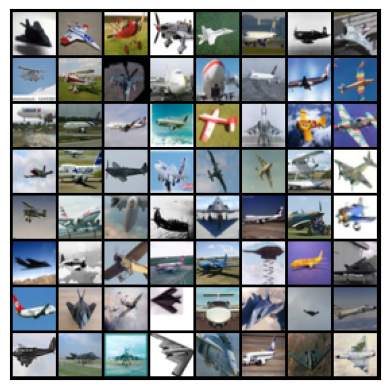

In [5]:
def show(imgs):
    if not isinstance(imgs, list):
        imgs = [imgs]

    fig, axs = plt.subplots(ncols=len(imgs), squeeze=False)
    for i, img in enumerate(imgs):
        img = img.detach()
        img = F.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])


sprites = np.load(data_dir / "sprites.npy")
dset_torch = torch.from_numpy(sprites)
images = make_grid(dset_torch[:64].permute(0, 3, 1, 2), nrow=8)
show(images)

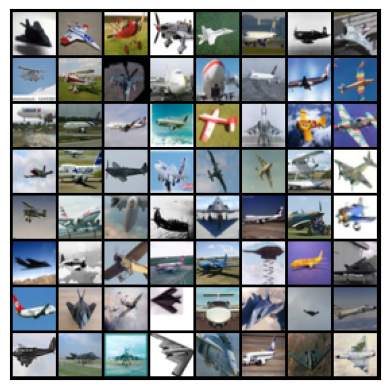

In [6]:
class SpriteDS(Dataset):
  def __init__(self, data_dir):
    data_dir = Path(data_dir)
    self.images = torch.from_numpy(np.load(data_dir / "sprites.npy")).float() / 255
    self.labels = torch.from_numpy(np.load(data_dir / "sprites_labels.npy")).float()

  def __len__(self):
      return self.images.shape[0]

  def __getitem__(self, idx):
      return self.images[idx], self.labels[idx]


dataset = SpriteDS(data_dir)

# class 2 = bird
mask = torch.argmax(dataset.labels, dim=-1) == 0
images = make_grid(dataset.images[mask][:64].permute(0, 3, 1, 2), nrow=8)
show(images)

epoch 09 | loss 0.2285: 100%|██████████| 10/10 [00:20<00:00,  2.08s/it]


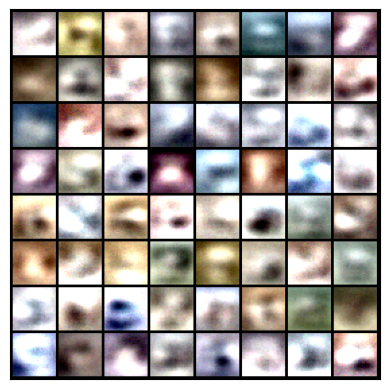

In [7]:
from ai_image_models.learner import Learner
from ai_image_models.models import FlowMLP

model = FlowMLP(img_shape=(32, 32, 3),h=128)
learner = Learner(model,lr=0.001)
learner.learn(dataset,epochs=10,batch_size=256)

new_images = learner.generate(64)
images = make_grid(new_images.permute(0, 3, 1, 2), nrow=8)
show(images)

In [8]:
model.state_dict().keys()
model.state_dict()['net.0.weight'].shape

torch.Size([128, 3200])

In [9]:
torch.save(model.state_dict(), "flow_mlp.pt")
print("saved flow_mlp.pt")

saved flow_mlp.pt


In [10]:
# from PIL import Image

# traj = learner.generate(n=64, trajectory=True)  # (steps, n, 16, 16, 3)

# frames = []

# for step in traj[::5]:
#     grid = make_grid(step.permute(0, 3, 1, 2), nrow=8)
#     arr = (grid.permute(1, 2, 0).numpy() * 255).astype("uint8")
#     frames.append(Image.fromarray(arr))

# frames[0].save(
#     "sprites.gif",
#     save_all=True,
#     append_images=frames[1:],
#     duration=10,
#     loop=0,
# )

epoch 09 | loss 0.0925: 100%|██████████| 10/10 [1:15:39<00:00, 453.94s/it]


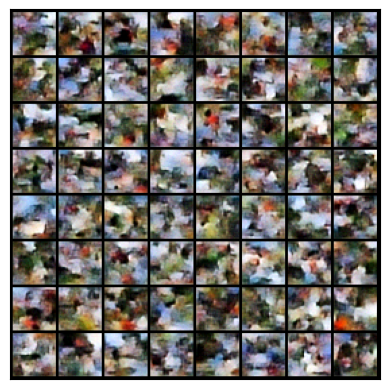

In [11]:
#use CNN
from ai_image_models.learner import Learner
from ai_image_models.models import FlowCNN

model = FlowCNN(img_shape=(32, 32, 3),t_dim=128,h=256)
learner = Learner(model,lr=0.0003)
learner.learn(dataset,epochs=10,batch_size=128)

new_images = learner.generate(64)
images = make_grid(new_images.permute(0, 3, 1, 2), nrow=8)
show(images)

In [12]:
torch.save(model.state_dict(), "flow_cnn.pt")
print("saved flow_cnn.pt")

saved flow_cnn.pt
